# Chapter 4: Timestep-Guided Flow Machine

## The Hidden Assumption We Broke

In the previous chapter, we built a flow machine as if the vector field was **static** — as if the rules of motion were the same everywhere in space.

But here's the truth: **The flow field changes over time.**

When noise is high, the field needs to push hard. When noise is low, the field should be gentle — almost like a river that's turbulent upstream and calm downstream.

## What were we doing wrong?

We told the model: "Here's a noisy image. Tell me how to move."

But we forgot to tell it: **"How noisy is this image, really?"**

It's like giving someone a map but not telling them where they are on it.

## The fix: Tell the model the time

By adding timestep `t` as an input, we're essentially saying:

> "Here's where you are in the denoising journey. Act accordingly."

- When `t` is large (very noisy) → be bold, make big moves
- When `t` is small (almost clean) → be careful, make tiny adjustments

The flow field is no longer a static map. It's a **time‑aware guide** that changes its behavior depending on how far along the journey we are.

## Intuition

Imagine you're in a foggy landscape (noise), trying to find your way home (clean image).

- Without timestep: You just know the direction, but not how far you are.
- With timestep: You know **both** — and you act differently when you're far vs. when you're almost there.

That's the magic of timestep conditioning. It turns a blind compass into a wise guide.

In [ ]:
import data
import utils
import torch
import models
from torch import nn, optim

## FlowMachine with timestep conditioning

The `SinusoidalTimestepEmbedder` creates a smooth, continuous embedding for `t` (similar to positional encoding in transformers).

This allows the model to:
- Distinguish between different noise levels
- Learn a **time-dependent vector field**

In [2]:
class FlowMachine(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            models.ResConvBlock(3 + 16, 32, 32, 8),
            models.SkipBlock(
                nn.AvgPool2d(2),
                models.ResConvBlock(32, 64, 64),
                models.SkipBlock(
                    nn.AvgPool2d(2),
                    models.ResConvBlock(64, 128, 128),
                    models.SkipBlock(
                        nn.AvgPool2d(2),
                        models.ResConvBlock(128, 256, 256),
                        models.PositionalEncoding2d(256),
                        models.SelfAttention(256),
                        models.ResConvBlock(256, 256, 128),
                        nn.Upsample(scale_factor=2, mode='bilinear'),
                    ),
                    models.ResConvBlock(256, 128, 64),
                    nn.Upsample(scale_factor=2, mode='bilinear'),
                ),
                models.ResConvBlock(128, 64, 32),
                nn.Upsample(scale_factor=2, mode='bilinear'),
            ),
            models.ResConvBlock(64, 32, 3, 8, last_layer=True),
        )
        self.timestep_embed = models.SinusoidalTimestepEmbedder(16)
    
    def forward(self, x):
        x, t = x
        t = self.timestep_embed(t)                # shape: (batch, 16)
        t = t[..., None, None]                    # add spatial dimensions
        t = t.repeat(1, 1, 32, 32)                # shape: (batch, 16, 32, 32)
        x = torch.cat([x, t], dim=1)              # concat along channel dim (3 + 16 = 19)
        return self.net(x)

model = FlowMachine()

## Dataset (same as Chapter 3)

The dataset returns noisy image `x` and flow target `y - noise`.

But now we also return the timestep `t` as part of the input!

In [3]:
class NoisyCIFAR10(torch.utils.data.Dataset):
    def __init__(self, train=True, normalize=False):
        self.cifar10 = data.get_cifar10(train=train, normalize=normalize)
    
    def __len__(self):
        return len(self.cifar10)
    
    def __getitem__(self, index):
        y, _ = self.cifar10[index]                    # clean image
        noise = torch.randn((3, 32, 32))              # random noise
        t = torch.rand(1)[0]                          # random noise level
        x = t * noise + (1 - t) * y                   # noisy image
        return (x, t), y - noise                      # input: (image, t), target: flow

dataloader = data.DataLoader(NoisyCIFAR10(), batch_size=50, shuffle=True)
optimizer = optim.Adam(model.parameters(), 1e-3)
loss_fn = nn.MSELoss()

## Sampling: Walking Backwards Through Time

In Chapter 3, we started from noise and moved forward. But time in a diffusion model flows from **clean → noise**.

To generate an image, we need to **reverse time**: start from pure noise (t=1) and walk backwards to the clean image (t=0).

At each step, we ask the model: "Given the current noise level (t), which direction should I move to become slightly cleaner?"

Then we take a small step in that direction. The step size is controlled by `1/steps` — smaller steps mean a more accurate (but slower) path.

By the time we reach step = 0, we should have arrived at a clean(ish) image.

In [4]:
@torch.no_grad()
def sample(num, steps):
    model.eval()
    images = torch.zeros((num * steps, 3, 32, 32))
    image = torch.randn((num, 3, 32, 32))                     # start from pure noise (t=1)
    
    for step in range(steps, 0, -1):                          # go backwards: steps ... 1
        t = step / steps                                      # current noise level (1.0 down to ~0)
        flow = model((image, torch.tensor(t).repeat(num,)))   # model predicts the flow field
        image = image + flow / steps                          # take a small step
        images[(steps - step) * num: (steps - step) * num + num] = image
        
    return images

## Training and Results

We first sample 8 images starting from pure noise (before any training). These will look like random static.

Then we train for 3 epochs. After each epoch, we sample again to see how the generated images improve.

With timestep conditioning, the model learns to behave differently at different noise levels, leading to cleaner and more coherent results.

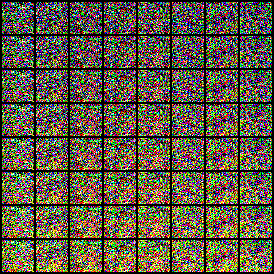

Loss: 0.123009: 100%|██████████| 1000/1000 [14:45<00:00,  1.13it/s]


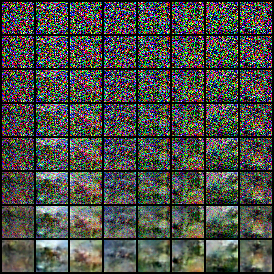

Loss: 0.109165: 100%|██████████| 1000/1000 [15:30<00:00,  1.07it/s]


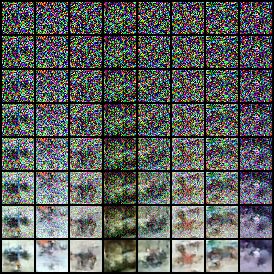

Loss: 0.103875: 100%|██████████| 1000/1000 [19:18<00:00,  1.16s/it]


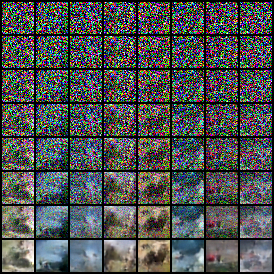

In [5]:
demo = sample(8, 8)
utils.show_image(demo)
for i in range(3):
    utils.train(model, dataloader, optimizer, loss_fn)
    demo = sample(8, 8)
    utils.show_image(demo)

## What Have We Learned?

| Without timestep | With timestep |
|------------------|---------------|
| The model is blind to noise level | The model knows exactly how noisy the input is |
| Same behavior at all noise levels | Behavior changes with noise level (adaptive) |
| Works poorly, especially in very low and high noise | Works much better, more stable training |

This small change — adding `t` as an input — is one of the **key ideas behind modern diffusion models** (DDPM, DDIM, etc.).

In fact, the model we just built is very close to a simplified version of **Denoising Diffusion Probabilistic Models (DDPM)**.

## A Peek Ahead: Class Conditioning

The same trick works for **text or class conditioning**!

Instead of feeding just the timestep `t`, we can also feed a class label (like "cat", "car", etc.).

The model then learns a **time-dependent and class-dependent flow field**:

```python
flow = model(noisy_image, t, class_label)
```


This is how modern models like Stable Diffusion let you say "a photo of a cat wearing a hat" and generate exactly that.

The method shown here (concatenating the conditioning to the input) is the simplest form. Real diffusion models use more advanced techniques like **cross-attention** — but the core idea is the same: **tell the model what you want, and it will guide the flow accordingly**.